

### 目標
本作業的核心是比較3種不同模型對預測效果的影響。
預測第 n+1 天的 close（收盤價）。

### 評估指標
- MSE


## Download Data and Import Libraries

In [ ]:
from pathlib import Path
from torchvision.datasets.utils import download_file_from_google_drive

csv_path_2308 = Path('./2308.csv')

if not csv_path_2308.exists():
    download_file_from_google_drive('1cRaFFJNaQYUewKHXoULhUTveuihOx6tU', '.', csv_path_2308)

Downloading...
From: https://drive.google.com/uc?id=1cRaFFJNaQYUewKHXoULhUTveuihOx6tU
To: /content/2308.csv
100%|██████████| 73.7k/73.7k [00:00<00:00, 53.2MB/s]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from sklearn.preprocessing import StandardScaler

In [ ]:
df_2308 = pd.read_csv(csv_path_2308)      # a DataFrame object
df_2308 = df_2308.sort_values(by='date')  # csv are not guarenteed to be ordered by date

df_2308.head(10)

,date,symbol,volume,open,high,low,close,transactions,daily_change_pct
6,2020/1/10,2308,6079101,152.5,154.5,149.5,151.0,2926,-0.0066
7,2020/1/13,2308,5115905,152.5,152.5,148.5,149.5,2963,-0.0099
8,2020/1/14,2308,4665147,150.5,151.5,149.5,151.0,2400,0.0100
9,2020/1/15,2308,9133097,151.0,151.0,147.5,148.5,3027,-0.0166
10,2020/1/16,2308,6949114,148.5,151.0,148.0,151.0,3646,0.0168
11,2020/1/17,2308,6215796,151.5,152.0,149.5,152.0,2833,0.0066
0,2020/1/2,2308,2721085,152.5,152.5,150.5,151.0,1764,0.0000
12,2020/1/20,2308,9947821,152.0,154.0,151.0,152.5,5624,0.0033
1,2020/1/3,2308,6932546,152.0,152.5,149.0,151.5,3386,0.0033
13,2020/1/30,2308,14343231,151.0,151.0,142.0,143.0,6747,-0.0623


### Train/Valid Split and Feature Normalization

We split first 85% of the entries to be training data, and last 15% to be validation data.
The pivot date is 2015-12-15, i.e., entries after 2015-12-15 (included) is valid data.


Note that scale of the features (`open`, `close`, `low`, `high`, `volume`) are different to each other. In practice, we normalize each features to better train our model. If we do so, the model will suffer gradient vanishment/exploding.

To normalize data, common techniques are:

1. Standard Scaler: $x_{new} = (x - mean) / std$
2. Minmax Scaler: $x_{new} = (x - x_{min}) / (x_{max} - x_{min})$

Both are implemented in `sklearn`. In this code, we use the first one.

**Be careful that when normalizing data, we can use only training data to compute the statistics. Using validation/testing data is not allowed.**


In some cases, we need to obtain original values from normalized features, we can do it using the standard scaler `std` used for normalization.

```python
raw_open = normalize_open* std.scale_[0] + std.mean_[0]
raw_close = normalized_close * std.scale_[1] + std.mean_[1]
raw_low = normalized_low * std.scale_[2] + std.mean_[2]
raw_high = normalized_low * std.scale_[3] + std.mean_[3]
raw_volume = normalized_low * std.scale_[4] + std.mean_[4]
```

In [ ]:
pivot = round(0.85 * len(df_2308))
print('pivot:', df_2308.loc[pivot, 'date'])

df_train = df_2308[:pivot].copy()    # DataFrame
df_valid = df_2308[pivot:].copy()    # DataFrame

FEATURES_STD = ['open', 'close', 'low', 'high', 'volume']
std = StandardScaler().fit(df_train[FEATURES_STD])
df_train[FEATURES_STD] = std.transform(df_train[FEATURES_STD])
df_valid[FEATURES_STD] = std.transform(df_valid[FEATURES_STD])

df_train.head(10)

pivot: 2024/4/9


,date,symbol,volume,open,high,low,close,transactions,daily_change_pct
6,2020/1/10,2308,-0.327612,-1.756288,-1.753827,-1.768659,-1.777471,2926,-0.0066
7,2020/1/13,2308,-0.552411,-1.756288,-1.785213,-1.784659,-1.801259,2963,-0.0099
8,2020/1/14,2308,-0.657612,-1.788023,-1.800906,-1.768659,-1.777471,2400,0.0100
9,2020/1/15,2308,0.385155,-1.780090,-1.808753,-1.800659,-1.817119,3027,-0.0166
10,2020/1/16,2308,-0.124561,-1.819758,-1.808753,-1.792659,-1.777471,3646,0.0168
11,2020/1/17,2308,-0.295709,-1.772156,-1.793060,-1.768659,-1.761611,2833,0.0066
0,2020/1/2,2308,-1.111334,-1.756288,-1.785213,-1.752659,-1.777471,1764,0.0000
12,2020/1/20,2308,0.575302,-1.764222,-1.761674,-1.744659,-1.753682,5624,0.0033
1,2020/1/3,2308,-0.128428,-1.764222,-1.785213,-1.776659,-1.769541,3386,0.0033
13,2020/1/30,2308,1.601139,-1.780090,-1.808753,-1.888659,-1.904345,6747,-0.0623


# Dataset

To predict the stock close on day 16 based on day 1 ~ day 15 features, we expect each sample contains:

1. feature: the features of day 1 ~ 15. Each day has 5 features (open, close, low, high, volume), thus the shape is [15, 5].
2. target: the target we are predicting. In this case, it is the close of day 16, thus target is shaped [1].

Therefore we are performing a sliding window-like operation on the given dataframe.

In [ ]:
class CompanyStockData(Dataset):
    def __init__(self, dataframe, window=10):
        super().__init__()
        self.df = dataframe
        self.window = window

    def __len__(self):
        return len(self.df) - self.window

    def __getitem__(self, idx):
        window_s = idx
        window_t = idx + self.window
        feature = self.df.iloc[window_s:window_t - 1]
        feature = feature[['open', 'close', 'low', 'high', 'volume']].values
        feature = torch.from_numpy(feature).float()

        target = self.df.iloc[window_t - 1]
        target = target['close'].item()
        target = torch.tensor([target]).float()
        return feature, target

WINDOW = 20
train_set = CompanyStockData(df_train, window=WINDOW)
valid_set = CompanyStockData(df_valid, window=WINDOW)

train_loader = DataLoader(train_set, shuffle=True, batch_size=8, num_workers=0)
valid_loader = DataLoader(valid_set, shuffle=False, batch_size=8, num_workers=0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"使用裝置: {device}")

使用裝置: cuda


# Model

We implements following model:



In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, num_layers=1, num_classes=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.regressor = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x, _ = self.lstm(x)
        return self.regressor(x[:, -1, :])

class BiLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, num_layers=1, num_classes=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x, _ = self.lstm(x)
        return self.fc(x[:, -1, :])

class GRU(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, num_layers=1, num_classes=1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x, _ = self.gru(x)
        return self.fc(x[:, -1, :])

Some other RNN model you can try:

# Training

Train the model in standard way and record losses every epoch.

In [ ]:
@torch.no_grad()
def evaluate_model(model, dataset):
    model.eval()
    preds, trues = [], []
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)
    for feature_b, target_b in loader:
        predict_b = model(feature_b.to(device)).to('cpu')
        preds.extend(predict_b)
        trues.extend(target_b)
    preds = torch.stack(preds).numpy()
    trues = torch.stack(trues).numpy()

    # 反標準化還原股價
    CLOSE_IDX = FEATURES_STD.index('close')
    preds = preds * std.scale_[CLOSE_IDX] + std.mean_[CLOSE_IDX]
    trues = trues * std.scale_[CLOSE_IDX] + std.mean_[CLOSE_IDX]

    mse = ((preds - trues) ** 2).mean()
    mae = np.abs(preds - trues).mean()
    return preds, trues, mse, mae

In [ ]:
# ==========================================
# 5. 核心：三大模型依序訓練與對比（修改版：30 Epochs，每 5 次列印）
# ==========================================
models_to_test = {
    'LSTM': LSTM(input_size=5, hidden_size=32),
    'BiLSTM': BiLSTM(input_size=5, hidden_size=32),
    'GRU': GRU(input_size=5, hidden_size=32)
}

# 用於儲存所有模型的歷史數據與預測結果
all_histories = {}
results = {}

# 💡 調整訓練輪數為 30
EPOCHS = 30

for name, model in models_to_test.items():
    print(f"\n======== 🚀 開始訓練模型: {name} ========")
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {'train_loss': [], 'valid_loss': []}

    for epoch in tqdm(range(EPOCHS), desc=f"{name} 訓練進度"):
        # Train
        model.train()
        train_losses = []
        for feature_b, target_b in train_loader:
            feature_b, target_b = feature_b.to(device), target_b.to(device)
            optimizer.zero_grad()
            predict_b = model(feature_b)
            loss = criterion(predict_b, target_b)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Valid
        model.eval()
        valid_losses = []
        with torch.no_grad():
            for feature_b, target_b in valid_loader:
                feature_b, target_b = feature_b.to(device), target_b.to(device)
                predict_b = model(feature_b)
                loss = criterion(predict_b, target_b)
                valid_losses.append(loss.item())

        current_train_loss = sum(train_losses) / len(train_losses)
        current_valid_loss = sum(valid_losses) / len(valid_losses)

        history['train_loss'].append(current_train_loss)
        history['valid_loss'].append(current_valid_loss)

        # 💡 每 5 次 (或是最後一次) 列出一次訓練結果
        # epoch 從 0 開始，所以 (epoch + 1) % 5 == 0 代表第 5, 10, 15, 20, 25, 30 次
        if (epoch + 1) % 5 == 0 or epoch == EPOCHS - 1:
            print(f"Epoch [{epoch+1:02d}/{EPOCHS}]: Train Loss = {current_train_loss:.6f} | Valid Loss = {current_valid_loss:.6f}")

    all_histories[name] = history

    # 評估模型表現
    train_preds, train_trues, train_mse, train_mae = evaluate_model(model, train_set)
    valid_preds, valid_trues, valid_mse, valid_mae = evaluate_model(model, valid_set)

    results[name] = {
        'train_preds': train_preds, 'train_trues': train_trues, 'train_mse': train_mse, 'train_mae': train_mae,
        'valid_preds': valid_preds, 'valid_trues': valid_trues, 'valid_mse': valid_mse, 'valid_mae': valid_mae
    }

    print(f"✨ {name} 訓練完成！ 最終 Valid MSE: {valid_mse:.3f} | 最終 Valid MAE: {valid_mae:.3f}")


======== 🚀 開始訓練模型: LSTM ========


LSTM 訓練進度:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [05/30]: Train Loss = 0.037623 | Valid Loss = 0.097090
Epoch [10/30]: Train Loss = 0.034102 | Valid Loss = 0.085153
Epoch [15/30]: Train Loss = 0.033574 | Valid Loss = 0.075960
Epoch [20/30]: Train Loss = 0.033436 | Valid Loss = 0.079777
Epoch [25/30]: Train Loss = 0.032312 | Valid Loss = 0.086902
Epoch [30/30]: Train Loss = 0.031793 | Valid Loss = 0.083153
✨ LSTM 訓練完成！ 最終 Valid MSE: 340.963 | 最終 Valid MAE: 11.988

======== 🚀 開始訓練模型: BiLSTM ========


BiLSTM 訓練進度:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [05/30]: Train Loss = 0.034336 | Valid Loss = 0.081566
Epoch [10/30]: Train Loss = 0.034025 | Valid Loss = 0.074565
Epoch [15/30]: Train Loss = 0.033198 | Valid Loss = 0.079280
Epoch [20/30]: Train Loss = 0.033238 | Valid Loss = 0.074261
Epoch [25/30]: Train Loss = 0.033491 | Valid Loss = 0.067877
Epoch [30/30]: Train Loss = 0.033019 | Valid Loss = 0.083653
✨ BiLSTM 訓練完成！ 最終 Valid MSE: 344.489 | 最終 Valid MAE: 12.705

======== 🚀 開始訓練模型: GRU ========


GRU 訓練進度:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [05/30]: Train Loss = 0.037032 | Valid Loss = 0.078123
Epoch [10/30]: Train Loss = 0.034982 | Valid Loss = 0.069538
Epoch [15/30]: Train Loss = 0.034092 | Valid Loss = 0.069941
Epoch [20/30]: Train Loss = 0.033107 | Valid Loss = 0.071417
Epoch [25/30]: Train Loss = 0.032957 | Valid Loss = 0.078272
Epoch [30/30]: Train Loss = 0.032024 | Valid Loss = 0.070312
✨ GRU 訓練完成！ 最終 Valid MSE: 286.338 | 最終 Valid MAE: 10.702



======== 📊 正在繪製綜合對比圖表... ========


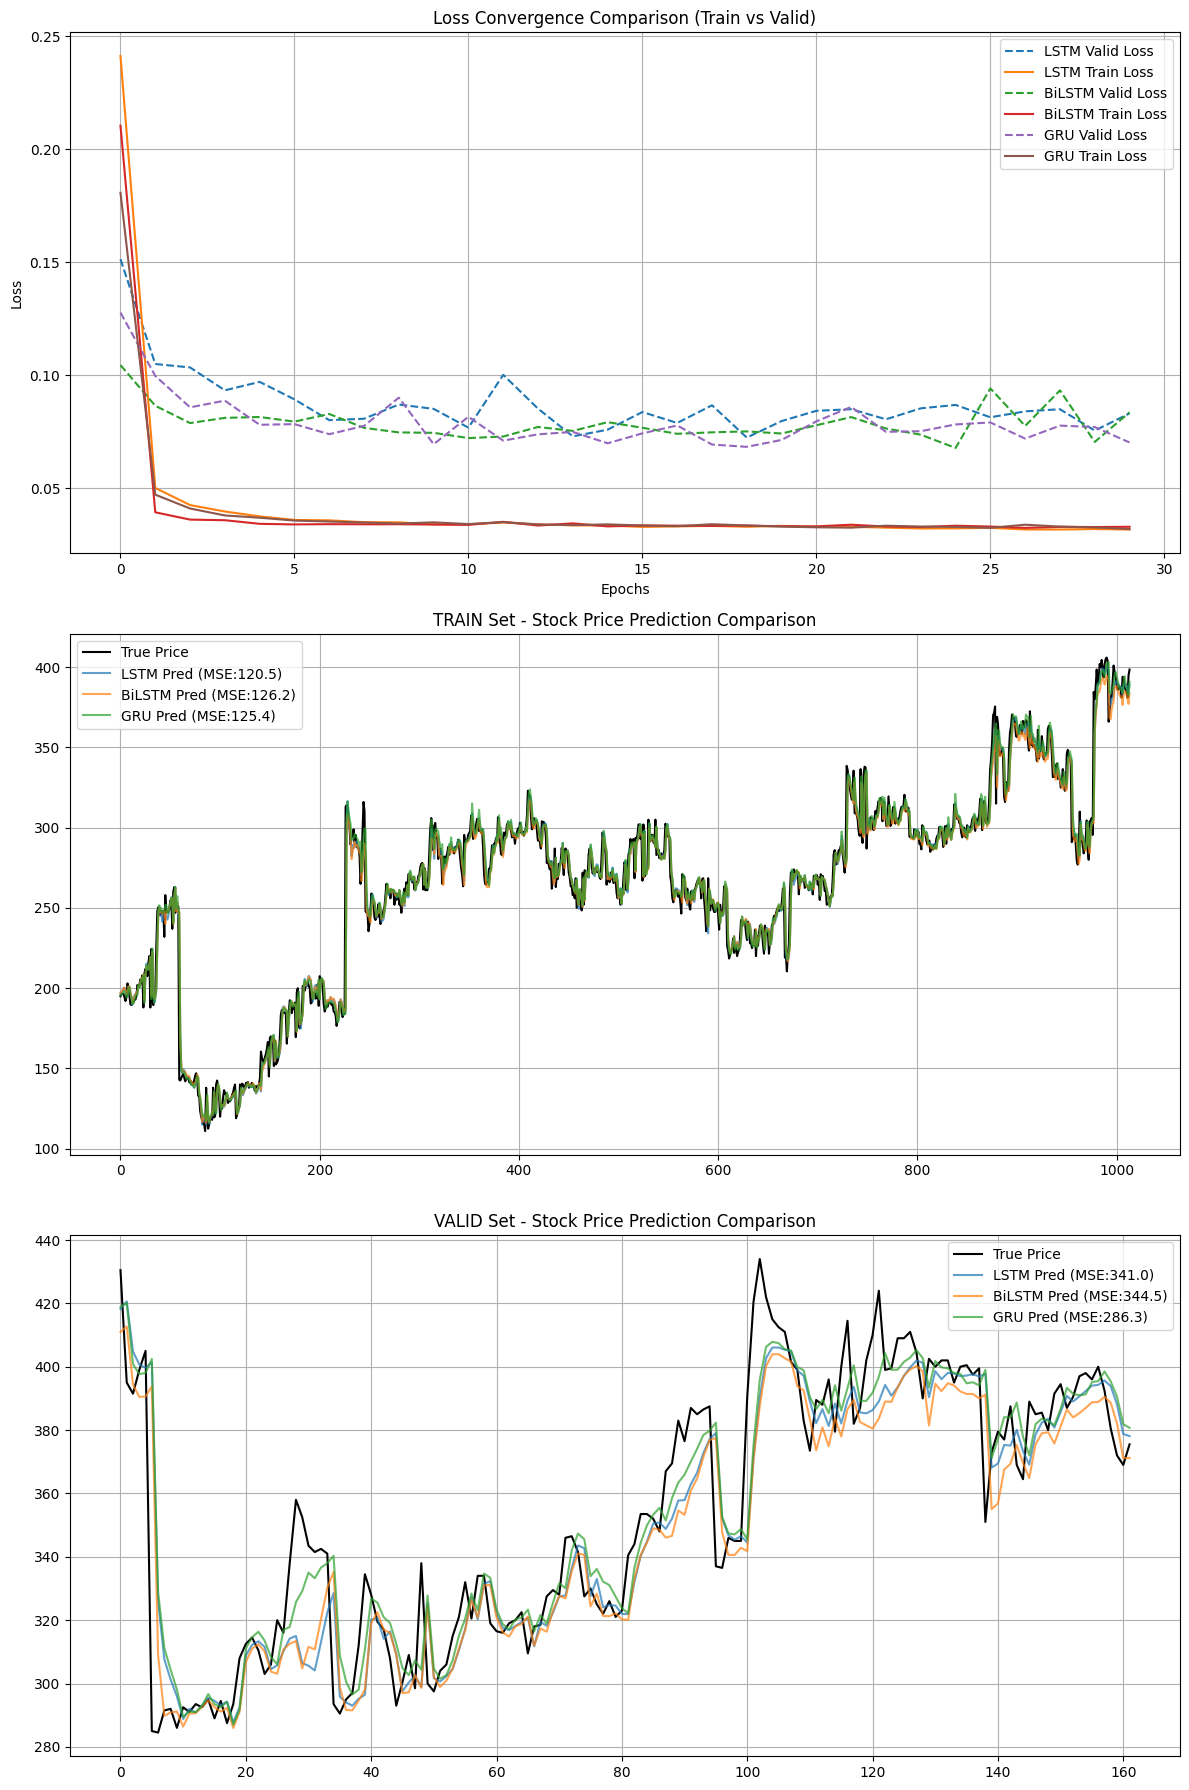


🔥 最終效能總結報告 🔥
[LSTM]
  - 訓練集 (Train) -> MSE: 120.476 | MAE: 6.664
  - 驗證集 (Valid) -> MSE: 340.963 | MAE: 11.988
[BiLSTM]
  - 訓練集 (Train) -> MSE: 126.169 | MAE: 6.740
  - 驗證集 (Valid) -> MSE: 344.489 | MAE: 12.705
[GRU]
  - 訓練集 (Train) -> MSE: 125.428 | MAE: 6.744
  - 驗證集 (Valid) -> MSE: 286.338 | MAE: 10.702


In [ ]:
print("\n======== 📊 正在繪製綜合對比圖表... ========")
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 圖(一)：Loss 曲線對比
for name in models_to_test.keys():
    axes[0].plot(all_histories[name]['valid_loss'], label=f'{name} Valid Loss', linestyle='--')
    axes[0].plot(all_histories[name]['train_loss'], label=f'{name} Train Loss')
axes[0].set_title('Loss Convergence Comparison (Train vs Valid)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 圖(二)：訓練集預測結果 (只畫真實值一次，疊加各模型預測)
any_name = list(models_to_test.keys())[0]
axes[1].plot(results[any_name]['train_trues'], label='True Price', color='black', linewidth=1.5)
for name in models_to_test.keys():
    mse, mae = results[name]['train_mse'], results[name]['train_mae']
    axes[1].plot(results[name]['train_preds'], label=f'{name} Pred (MSE:{mse:.1f})', alpha=0.7)
axes[1].set_title('TRAIN Set - Stock Price Prediction Comparison')
axes[1].legend()
axes[1].grid(True)

# 圖(三)：驗證集預測結果
axes[2].plot(results[any_name]['valid_trues'], label='True Price', color='black', linewidth=1.5)
for name in models_to_test.keys():
    mse, mae = results[name]['valid_mse'], results[name]['valid_mae']
    axes[2].plot(results[name]['valid_preds'], label=f'{name} Pred (MSE:{mse:.1f})', alpha=0.7)
axes[2].set_title('VALID Set - Stock Price Prediction Comparison')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# 列印最後的文字版效能總結
print("\n" + "="*40 + "\n🔥 最終效能總結報告 🔥\n" + "="*40)
for name in models_to_test.keys():
    print(f"[{name}]")
    print(f"  - 訓練集 (Train) -> MSE: {results[name]['train_mse']:.3f} | MAE: {results[name]['train_mae']:.3f}")
    print(f"  - 驗證集 (Valid) -> MSE: {results[name]['valid_mse']:.3f} | MAE: {results[name]['valid_mae']:.3f}")

In [ ]:
!pip install onnxscript onnx
import torch
from google.colab import files

print("======== 📦 開始將模型轉換為 ONNX 格式 ========")

# 1. 定義虛擬輸入 (Dummy Input)
# 根據你的程式碼：batch_size=1 (轉換只需1筆範例), window-1 = 19 (特徵長度), features = 5
# 註：CompanyStockData 內取 feature 是 window_s:window_t-1，所以時間步長是 WINDOW - 1
dummy_input = torch.randn(1, WINDOW - 1, 5).to('cpu')

# 2. 依序轉換每個模型
for name, model in models_to_test.items():
    # 將模型移回 CPU 並設定為評估模式（這點對 LSTM/GRU 的 Dropout/Batch_First 非常重要）
    model_cpu = model.to('cpu')
    model_cpu.eval()

    onnx_filename = f"{name}_stock_model.onnx"

    # 執行 ONNX 匯出
    torch.onnx.export(
        model_cpu,                  # 欲轉換的模型
        dummy_input,                # 虛擬輸入資料
        onnx_filename,              # 輸出的檔案名稱
        export_params=True,         # 包含訓練好的權重參數
        opset_version=12,           # 建議使用 opset 11 或 12，對 RNN 系列家族最穩定
        do_constant_folding=True,   # 執行常數折疊優化
        input_names=['input_features'],   # 自訂輸入節點名稱
        output_names=['predict_price'],  # 自訂輸出節點名稱
        # 允許隨後的部署環境，動態調整 Batch Size (例如一次預測 1 筆或 32 筆)
        dynamic_axes={
            'input_features': {0: 'batch_size'},
            'predict_price': {0: 'batch_size'}
        }
    )
    print(f"✅ 成功轉換：{onnx_filename}")

print("\n======== 📥 正在為您下載 ONNX 檔案至本機... ========")

# 3. 自動觸發瀏覽器下載這三個 ONNX 檔案
for name in models_to_test.keys():
    onnx_filename = f"{name}_stock_model.onnx"
    files.download(onnx_filename)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.7 MB/s eta 0:00:00
======== 📦 開始將模型轉換為 ONNX 格式 ========


/tmp/ipykernel_600/3300947812.py:21: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0606 11:54:24.614000 600 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `LSTM([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.lstm._flat_weights[0], self.lstm._flat_weights[1], self.lstm._flat_weights[2], self.lstm._flat_weights[3] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `LSTM([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>